<a href="https://colab.research.google.com/github/balasri03/Mini_project/blob/main/pstance_bert_bart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

dharanimanchala_pstance_path = kagglehub.dataset_download('dharanimanchala/pstance')

print('Data source import complete.')


In [ ]:
import re
import torch
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
import pandas as pd
import time
from collections import Counter
import numpy as np

In [ ]:
train_df = pd.read_csv("/kaggle/input/datasets/dharanimanchala/pstance/trainmerged (4).csv")
val_df = pd.read_csv("/kaggle/input/datasets/dharanimanchala/pstance/valmerged (3).csv")
test_df = pd.read_csv("/kaggle/input/datasets/dharanimanchala/pstance/testmerged (3).csv")

In [ ]:
train_df.shape

(17224, 3)

In [ ]:
print(train_df["Stance"].value_counts())

Stance
AGAINST    8877
FAVOR      8347
Name: count, dtype: int64


In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)          # remove URLs
    text = re.sub(r"@\w+", "", text)                    # remove mentions
    text = re.sub(r"#", "", text)                       # remove hashtags
    text = re.sub(r"[^a-z\s]", "", text)                # keep only letters
    text = re.sub(r"\s+", " ", text).strip()            # remove extra spaces
    return text


train_df["clean_text"] = (train_df["Tweet"] + " " + train_df["Target"]).apply(clean_text)

val_df["clean_text"] = (val_df["Tweet"] + " " + val_df["Target"]).apply(clean_text)

test_df["clean_text"] = (test_df["Tweet"] + " " + test_df["Target"]).apply(clean_text)

In [ ]:
from collections import Counter

def build_vocab(texts, min_freq=5):
    counter = Counter()

    for text in texts:
        words = text.split()
        counter.update(words)

    vocab = {"<pad>": 0, "<unk>": 1}

    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)

    return vocab


vocab = build_vocab(train_df["clean_text"])

In [ ]:
def text_to_seq(text, vocab):
    words = text.split()

    return [
        vocab.get(word, vocab["<unk>"])
        for word in words
    ]

In [ ]:
train_df["input_text"] = train_df["clean_text"] + " " + train_df["Target"]
val_df["input_text"]   = val_df["clean_text"]   + " " + val_df["Target"]
test_df["input_text"]  = test_df["clean_text"]  + " " + test_df["Target"]

vocab = build_vocab(train_df["input_text"].tolist())

print(f"Vocab size: {len(vocab)}")

Vocab size: 6488


In [ ]:
label_col = "Stance"

unique_labels = sorted(train_df[label_col].unique())

label2id = {label: idx for idx, label in enumerate(unique_labels)}

id2label = {v: k for k, v in label2id.items()}

print("Label mapping:", label2id)

Label mapping: {'AGAINST': 0, 'FAVOR': 1}


In [ ]:
# STEP 1: text → sequence

X_train = [text_to_seq(text, vocab) for text in train_df["input_text"]]

X_val   = [text_to_seq(text, vocab) for text in val_df["input_text"]]

X_test  = [text_to_seq(text, vocab) for text in test_df["input_text"]]

In [ ]:
# STEP 2: limit vocab

max_words = 2000

X_train_oh = [[min(i, max_words-1) for i in seq] for seq in X_train]

X_val_oh   = [[min(i, max_words-1) for i in seq] for seq in X_val]

X_test_oh  = [[min(i, max_words-1) for i in seq] for seq in X_test]

In [ ]:
!pip install transformers -q

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import time

from transformers import AutoTokenizer, BertModel, get_linear_schedule_with_warmup
from torch.optim import AdamW

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
label_map = {
    "AGAINST":0,
    "FAVOR":1,
    "NONE":2
}

y_train = train_df["Stance"].map(label_map).values
y_val = val_df["Stance"].map(label_map).values
y_test = test_df["Stance"].map(label_map).values

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

MAX_LEN = 128

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
class BertDataset(Dataset):

    def __init__(self, texts, labels, tokenizer, max_len):

        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [ ]:
train_dataset = BertDataset(train_df["Tweet"].values, y_train, tokenizer, MAX_LEN)
val_dataset = BertDataset(val_df["Tweet"].values, y_val, tokenizer, MAX_LEN)
test_dataset = BertDataset(test_df["Tweet"].values, y_test, tokenizer, MAX_LEN)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [ ]:
class BertClassifier(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.bert = BertModel.from_pretrained("bert-base-uncased")

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(768, num_classes)

    def forward(self, input_ids, attention_mask):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_output = outputs.last_hidden_state[:,0,:]

        x = self.dropout(cls_output)

        return self.fc(x)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

model = BertClassifier(num_classes=3)

model = model.to(device)

Device: cuda


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
optimizer = AdamW(model.parameters(), lr=2e-5)

epochs = 4

total_steps = len(train_loader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

criterion = nn.CrossEntropyLoss()

In [ ]:
train_start = time.time()

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for step, batch in enumerate(train_loader):

        if step % 100 == 0:
            print("Epoch:", epoch+1, "Batch:", step)

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids, attention_mask)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        scheduler.step()

        total_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", total_loss/len(train_loader))

train_end = time.time()

print("Training Time (hours):", (train_end-train_start)/3600)

Epoch: 1 Batch: 0
Epoch: 1 Batch: 100
Epoch: 1 Batch: 200
Epoch: 1 Batch: 300
Epoch: 1 Batch: 400
Epoch: 1 Batch: 500
Epoch: 1 Loss: 0.5664251666232695
Epoch: 2 Batch: 0
Epoch: 2 Batch: 100
Epoch: 2 Batch: 200
Epoch: 2 Batch: 300
Epoch: 2 Batch: 400
Epoch: 2 Batch: 500
Epoch: 2 Loss: 0.4208320751095084
Epoch: 3 Batch: 0
Epoch: 3 Batch: 100
Epoch: 3 Batch: 200
Epoch: 3 Batch: 300
Epoch: 3 Batch: 400
Epoch: 3 Batch: 500
Epoch: 3 Loss: 0.28936653820614644
Epoch: 4 Batch: 0
Epoch: 4 Batch: 100
Epoch: 4 Batch: 200
Epoch: 4 Batch: 300
Epoch: 4 Batch: 400
Epoch: 4 Batch: 500
Epoch: 4 Loss: 0.17963822633511833
Training Time (hours): 0.40681718389193217


In [ ]:
model.eval()

preds = []
true = []

infer_start = time.time()

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"]

        outputs = model(input_ids, attention_mask)

        _, predicted = torch.max(outputs, 1)

        preds.extend(predicted.cpu().numpy())
        true.extend(labels.numpy())

infer_end = time.time()

infer_time_seconds = infer_end - infer_start

In [ ]:
accuracy = accuracy_score(true, preds)
precision = precision_score(true, preds, average="weighted")
recall = recall_score(true, preds, average="weighted")
f1 = f1_score(true, preds, average="weighted")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

print("Inference Time:", infer_time_seconds)

Accuracy: 0.7756142790913305
Precision: 0.7755581444087604
Recall: 0.7756142790913305
F1: 0.7754357389858102
Inference Time: 16.09096074104309


In [ ]:
total_params = sum(p.numel() for p in model.parameters())

params_million = total_params / 1e6

print("Parameters (M):", params_million)

Parameters (M): 109.484547


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import torch.nn.functional as F

model.eval()

preds = []
true = []
probs = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"]

        outputs = model(input_ids, attention_mask)

        probabilities = F.softmax(outputs, dim=1)

        _, predicted = torch.max(outputs, 1)

        preds.extend(predicted.cpu().numpy())
        true.extend(labels.numpy())
        probs.extend(probabilities.cpu().numpy())

In [ ]:
from sklearn.preprocessing import label_binarize

n_classes = 3

true_bin = label_binarize(true, classes=[0,1,2])

probs = np.array(probs)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(true_bin[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


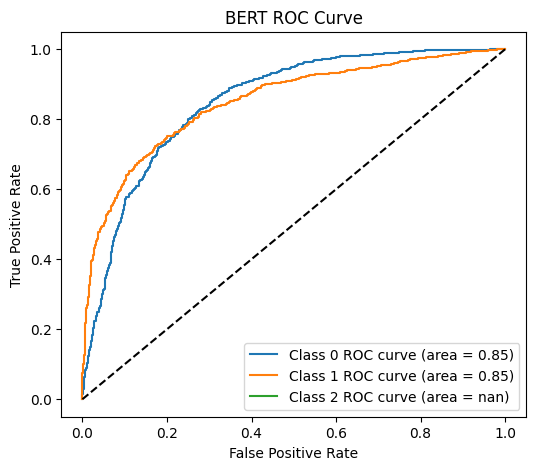

In [ ]:
plt.figure(figsize=(6,5))

for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"Class {i} ROC curve (area = {roc_auc[i]:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("BERT ROC Curve")

plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true, preds)

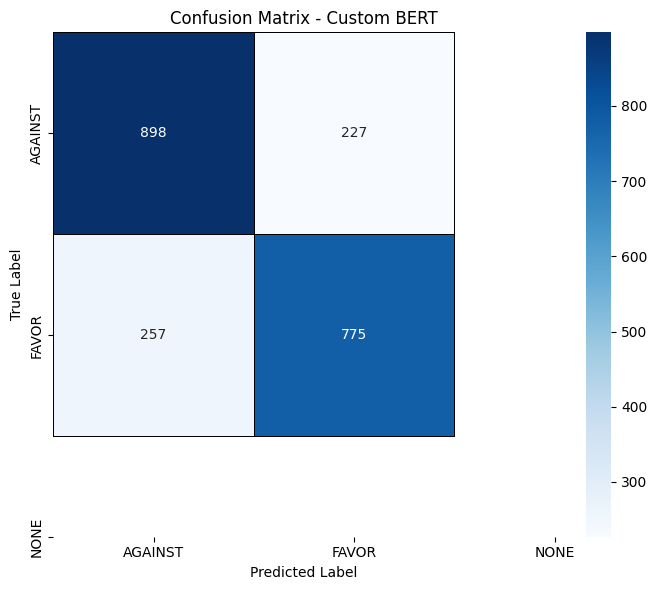

In [ ]:
# Class labels (important for readability)
labels = ["AGAINST", "FAVOR", "NONE"]
import seaborn as sns
plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    linecolor='black',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Custom BERT")

plt.tight_layout()
plt.show()

bart

In [ ]:
!pip install transformers datasets -q

import pandas as pd
import numpy as np
import torch
import time

from transformers import BartTokenizer, BartForSequenceClassification
from transformers import get_linear_schedule_with_warmup

from torch.optim import AdamW

from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
label_encoder = LabelEncoder()

train_df["label"] = label_encoder.fit_transform(train_df["Stance"])
val_df["label"]   = label_encoder.transform(val_df["Stance"])
test_df["label"]  = label_encoder.transform(test_df["Stance"])

num_classes = len(label_encoder.classes_)

print("Classes:", label_encoder.classes_)

Classes: ['AGAINST' 'FAVOR']


In [ ]:
tokenizer = BartTokenizer.from_pretrained("facebook/bart-base")

MAX_LEN = 128

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
class BartDataset(Dataset):

    def __init__(self, texts, labels, tokenizer, max_len=128):

        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [ ]:
train_dataset = BartDataset(train_df["Tweet"].values, train_df["label"].values, tokenizer)
val_dataset   = BartDataset(val_df["Tweet"].values, val_df["label"].values, tokenizer)
test_dataset  = BartDataset(test_df["Tweet"].values, test_df["label"].values, tokenizer)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16)
test_loader  = DataLoader(test_dataset, batch_size=16)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BartForSequenceClassification.from_pretrained(
    "facebook/bart-base",
    num_labels=num_classes
)

model = model.to(device)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

BartForSequenceClassification LOAD REPORT from: facebook/bart-base
Key                                 | Status  | 
------------------------------------+---------+-
classification_head.out_proj.bias   | MISSING | 
classification_head.dense.bias      | MISSING | 
classification_head.dense.weight    | MISSING | 
classification_head.out_proj.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
epochs = 4

optimizer = AdamW(model.parameters(), lr=2e-5)

total_steps = len(train_loader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

In [ ]:
train_start = time.time()

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for batch in train_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss

        loss.backward()

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", total_loss/len(train_loader))

train_end = time.time()

train_time_hours = (train_end - train_start)/3600

print("Training Time (hours):", train_time_hours)

Epoch: 1 Loss: 0.5140780453451718
Epoch: 2 Loss: 0.41067784516177136
Epoch: 3 Loss: 0.3306277199867099
Epoch: 4 Loss: 0.2723082457336155
Training Time (hours): 0.5161908595429526


In [ ]:
model.eval()

preds = []
true = []

infer_start = time.time()

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"]

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        _, predicted = torch.max(outputs.logits, 1)

        preds.extend(predicted.cpu().numpy())
        true.extend(labels.numpy())

infer_end = time.time()

infer_time = infer_end - infer_start

In [ ]:
accuracy = accuracy_score(true, preds)
precision = precision_score(true, preds, average="weighted")
recall = recall_score(true, preds, average="weighted")
f1 = f1_score(true, preds, average="weighted")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Inference Time:", infer_time)

Accuracy: 0.8071395456652758
Precision: 0.807102704212271
Recall: 0.8071395456652758
F1 Score: 0.8071148713468672
Inference Time: 18.336124897003174


In [ ]:
total_params = sum(p.numel() for p in model.parameters())

params_million = total_params / 1e6

print("Parameters (M):", params_million)

Parameters (M): 140.012546
